Сделать предсказание для сигнала из ЛР5 одним из методов выше.
Метод - сингулярный спектральный анализ

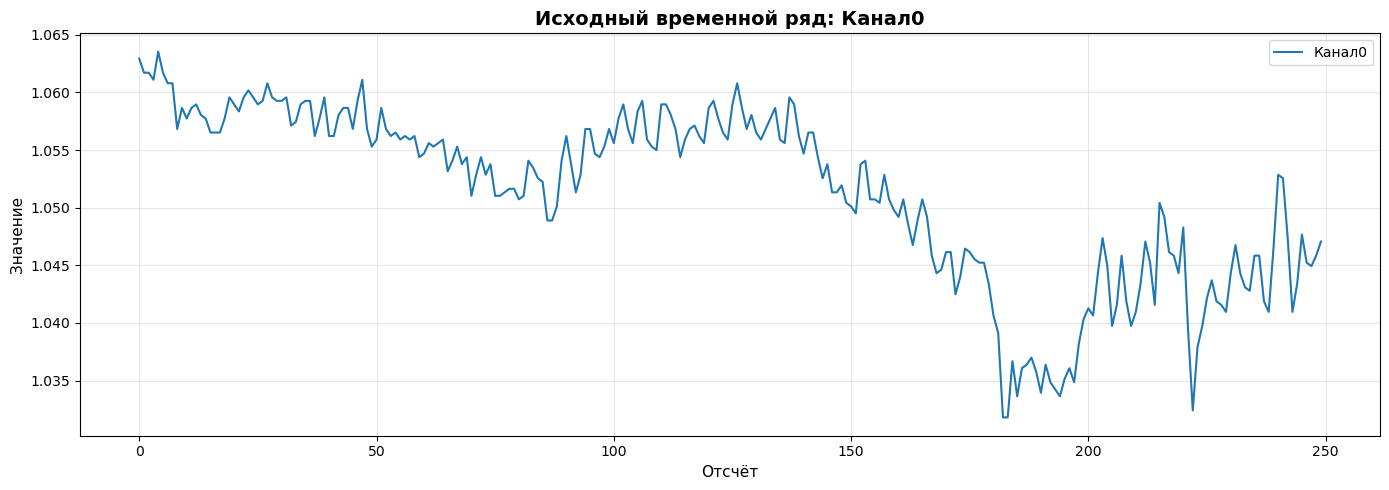


Параметры SSA: L = 25, K = 226
Траекторная матрица: (25, 226)


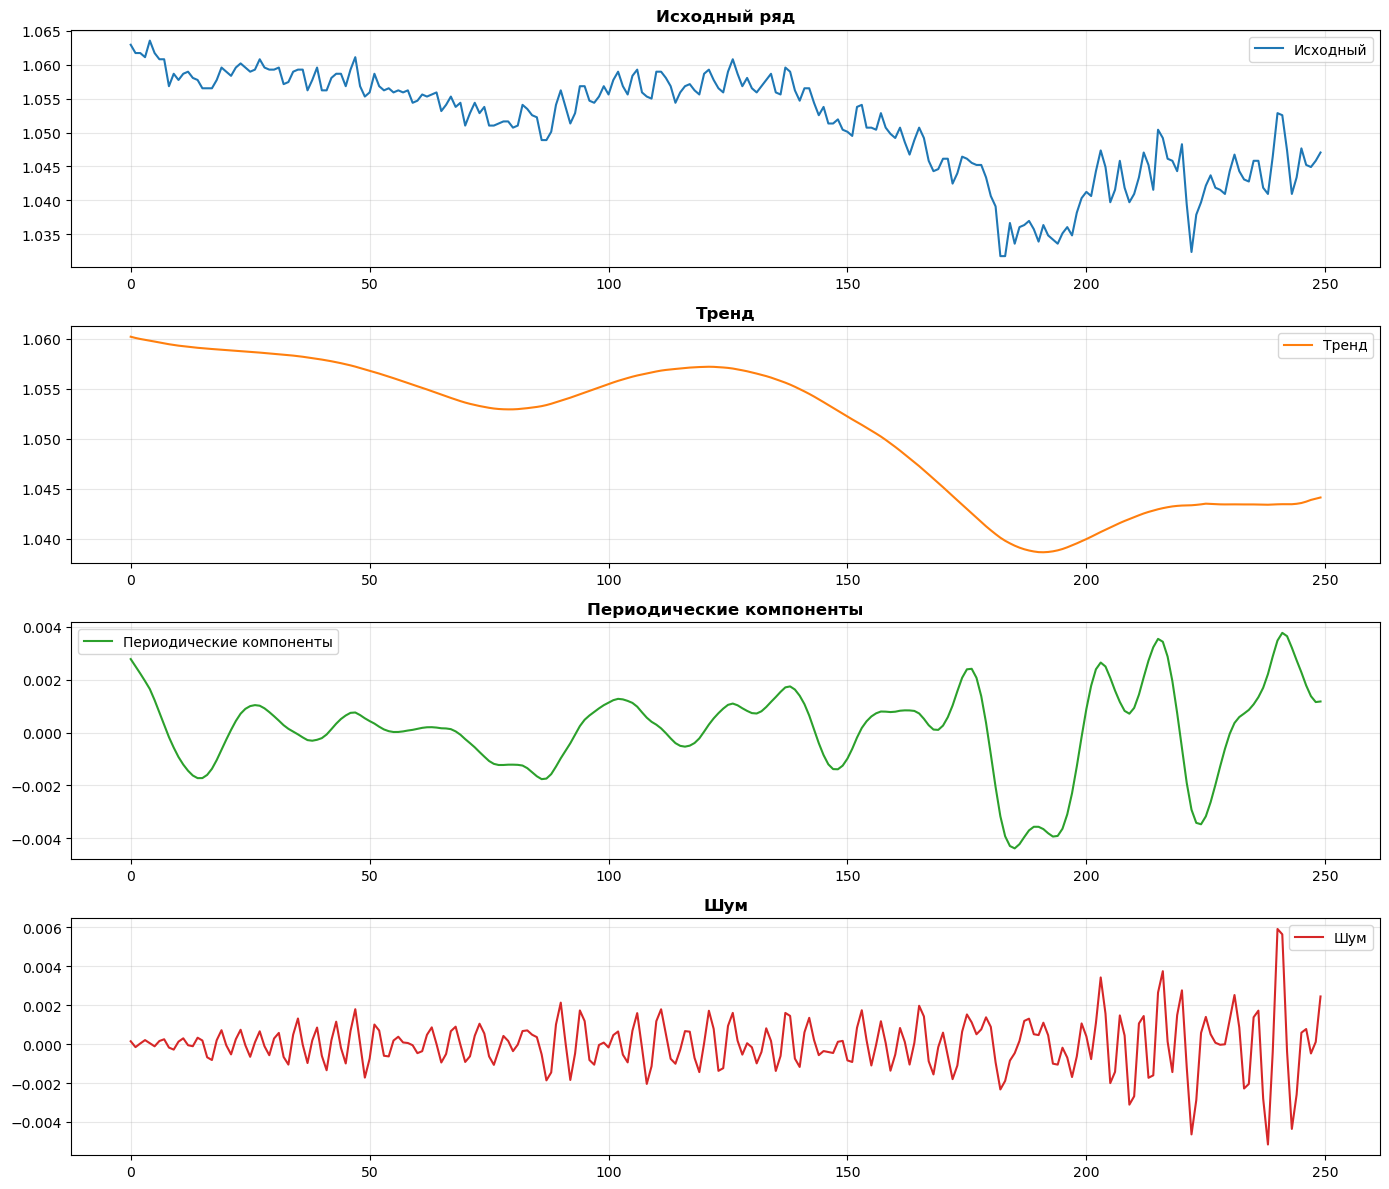

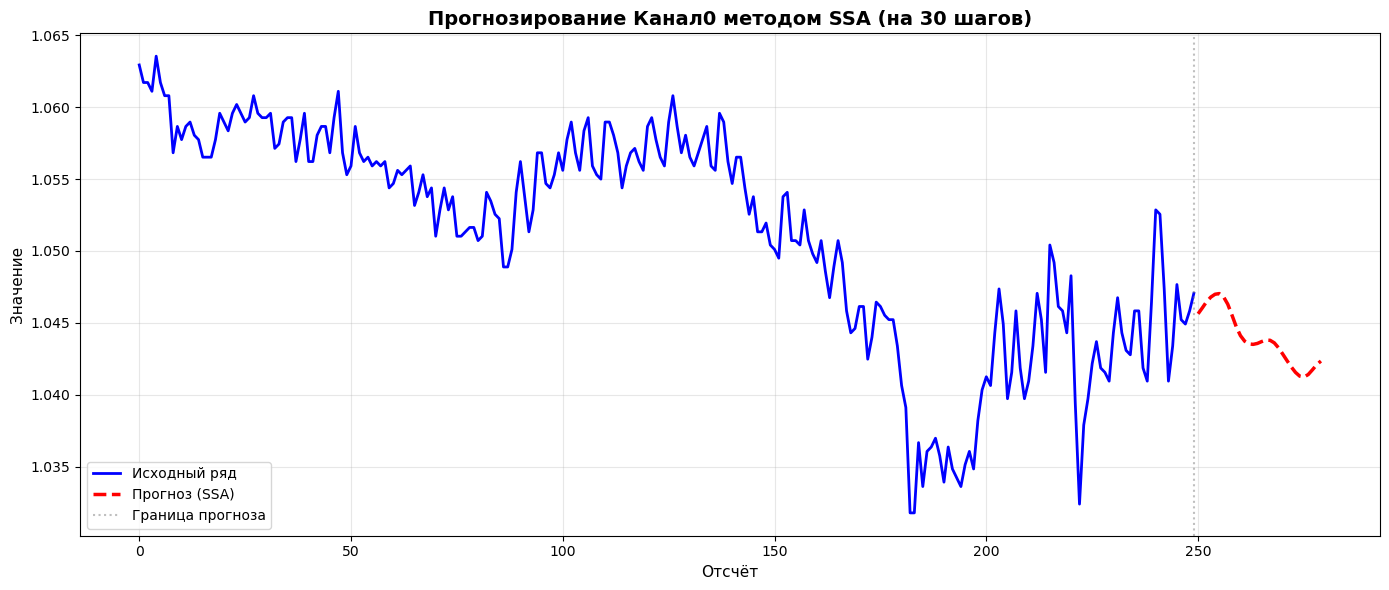

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('../05_lab/data/lab5_data6.txt', sep=';')

channel = 'Канал0'
series = data[channel].values.astype(float)
N = len(series)

plt.figure(figsize=(14, 5))
plt.plot(series, linewidth=1.5, label=channel)
plt.title(f'Исходный временной ряд: {channel}', fontsize=14, fontweight='bold')
plt.xlabel('Отсчёт', fontsize=11)
plt.ylabel('Значение', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

class SSA:
    """
    Singular Spectrum Analysis для декомпозиции и прогнозирования
    """
    
    def __init__(self, series, window_length):
        """
        Parameters:
        -----------
        series : array-like - временной ряд
        window_length : int - длина окна L (1 < L < N/2)
        """
        self.series = np.asarray(series, dtype=float)
        self.N = len(self.series)
        self.L = window_length
        self.K = self.N - self.L + 1  # число столбцов в траекторной матрице
        
    def embedding(self):
        """Шаг 1: Вложение - построение траекторной матрицы"""
        X = np.zeros((self.L, self.K))
        for i in range(self.K):
            X[:, i] = self.series[i:i + self.L]
        self.trajectory_matrix = X
        return X
    
    def decomposition(self):
        """Шаг 2: SVD-разложение траекторной матрицы"""
        X = self.trajectory_matrix
        # SVD: X = U * diag(S) * Vt
        U, S, Vt = svd(X, full_matrices=False)
        self.U = U
        self.S = S
        self.Vt = Vt
        # Собственные значения (вклад компонент)
        self.eigenvalues = S**2
        self.contributions = self.eigenvalues / np.sum(self.eigenvalues) * 100
        return U, S, Vt
    
    def grouping(self, groups):
        """
        Шаг 3: Группировка собственных троек
        groups : list of lists - индексы компонент для группировки
        """
        self.reconstructed_components = []
        
        for group in groups:
            # Суммируем матрицы ранга 1 для компонент из группы
            X_group = np.zeros_like(self.trajectory_matrix)
            for i in group:
                if i < len(self.S):
                    X_group += self.S[i] * np.outer(self.U[:, i], self.Vt[i])
            
            # Диагональное усреднение для восстановления ряда
            recon = self.diagonal_averaging(X_group)
            self.reconstructed_components.append(recon)
        
        return self.reconstructed_components
    
    def diagonal_averaging(self, matrix):
        """Диагональное усреднение: матрица -> временной ряд"""
        L, K = matrix.shape
        result = np.zeros(L + K - 1)
        counts = np.zeros(L + K - 1)
        
        for i in range(L):
            for j in range(K):
                result[i + j] += matrix[i, j]
                counts[i + j] += 1
        
        # Нормировка по числу элементов на диагонали
        result /= counts
        return result
    
    def forecast_recurrent(self, n_forecast, components_idx):
        """
        Прогнозирование с помощью рекуррентного алгоритма SSA
        components_idx : список индексов компонент для прогнозирования
        n_forecast : число шагов вперёд
        """
        # Восстанавливаем ряд по выбранным компонентам
        X_rec = np.zeros_like(self.trajectory_matrix)
        for i in components_idx:
            if i < len(self.S):
                X_rec += self.S[i] * np.outer(self.U[:, i], self.Vt[i])
        
        # Восстановленный ряд
        series_rec = self.diagonal_averaging(X_rec)
        
        # Рекуррентное прогнозирование
        # Находим веса линейной рекурсии из последней строки V-матрицы
        V = self.Vt[components_idx].T @ np.diag(self.S[components_idx])
        if len(components_idx) == 1:
            V = self.Vt[components_idx[0]].reshape(-1, 1) * self.S[components_idx[0]]
        
        # Альтернатива: используем коэффициенты из собственных векторов
        # w = -U[:-1, -1] / U[-1, -1]  # не всегда устойчиво
        
        # Более надёжный способ: линейная рекурсия через последние собственные векторы
        # Используем метод наименьших квадратов для нахождения коэффициентов
        L_star = self.L - 1
        if L_star <= 0:
            L_star = max(1, self.L // 2)
        
        # Строим систему для нахождения коэффициентов рекурсии
        # y(t) = a1*y(t-1) + a2*y(t-2) + ... + aL*y(t-L)
        A = np.zeros((self.K - 1, L_star))
        b = np.zeros(self.K - 1)
        for i in range(L_star, self.N - 1):
            A[i - L_star] = series_rec[i - L_star:i][::-1]
            b[i - L_star] = series_rec[i]
        
        # Решаем методом наименьших квадратов
        try:
            coeffs, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        except:
            coeffs = np.zeros(L_star)
        
        # Прогнозируем
        forecast = list(series_rec.copy())
        for _ in range(n_forecast):
            next_val = np.dot(coeffs, forecast[-L_star:][::-1])
            forecast.append(next_val)
        
        return np.array(forecast)
    
    def plot_components(self, titles=None):
        """Визуализация восстановленных компонент"""
        n_comp = len(self.reconstructed_components)
        fig, axes = plt.subplots(n_comp + 1, 1, figsize=(14, 3*(n_comp+1)))
        
        # Исходный ряд
        axes[0].plot(self.series, label='Исходный', linewidth=1.5)
        axes[0].set_title('Исходный ряд', fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        
        # Компоненты
        for i, comp in enumerate(self.reconstructed_components):
            idx = i + 1
            title = titles[i] if titles and i < len(titles) else f'Компонента {i+1}'
            axes[idx].plot(comp, label=title, linewidth=1.5, color=f'C{idx}')
            axes[idx].set_title(title, fontweight='bold')
            axes[idx].grid(True, alpha=0.3)
            axes[idx].legend()
        
        plt.tight_layout()
        plt.show()


# ==================== 3. ПРИМЕНЕНИЕ SSA ====================
# Выбираем длину окна (эмпирически: от N/10 до N/3)
L = 25  # длина окна
print(f"\nПараметры SSA: L = {L}, K = {N - L + 1}")

ssa = SSA(series, window_length=L)

X = ssa.embedding()

U, S, Vt = ssa.decomposition()

# Группируем: [0] - тренд, [1:5] - периодические, [5:] - шум (настраивается)
groups = [[0], [1, 2, 3], list(range(4, min(10, len(S))))]
reconstructed = ssa.grouping(groups)

# Визуализация компонент
ssa.plot_components(titles=['Тренд', 'Периодические компоненты', 'Шум'])

n_forecast = 30  # прогнозируем на 30 шагов вперёд

# Прогноз по основным компонентам (тренд + периодичности)
forecast_components = [0, 1, 2, 3]  # индексы компонент для прогноза
full_forecast = ssa.forecast_recurrent(n_forecast, forecast_components)

plt.figure(figsize=(14, 6))
plt.plot(series, label='Исходный ряд', linewidth=2, color='blue')
plt.plot(range(N, N + n_forecast), full_forecast[N:], 
         label='Прогноз (SSA)', linewidth=2.5, color='red', linestyle='--')
plt.axvline(x=N-1, color='gray', linestyle=':', alpha=0.5, label='Граница прогноза')
plt.title(f'Прогнозирование {channel} методом SSA (на {n_forecast} шагов)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Отсчёт', fontsize=11)
plt.ylabel('Значение', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()